In [43]:
import os
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import json
import os
from PIL import Image
import torch
from torch.utils.data import Dataset

from aichallenger import single_task, multi_task, tomato_task


class AIChallengerMultiTaskDataset(Dataset):
    def __init__(self, root_dir, img_split, transform=None):
        self.root_dir = root_dir
        self.img_split = img_split
        self.transform = transform

        self.data = self.__load_files()

        self.species_ids = [self.__label_id('species', d[1]) for d in self.data]
        self.disease_ids = [self.__label_id('disease', d[2]) for d in self.data]
        self.severity_ids = [self.__label_id('severity', d[3]) for d in self.data]

    def __len__(self):
        return len(self.data)
    
    def __load_files(self):
        data = []


        img_dir = os.path.join(self.root_dir, self.img_split, "images")
        if self.img_split == "AgriculturalDisease_trainingset":
            annotation_file = "AgriculturalDisease_train_annotations.json"
        elif self.img_split == "AgriculturalDisease_validationset":
            annotation_file = "AgriculturalDisease_validation_annotations.json"
        else:
            raise ValueError(f"Unknown split: {self.img_split}")

        with open(os.path.join(self.root_dir, self.img_split, annotation_file), "r") as f:
            all_labels = json.load(f)

        img_to_class = {entry["image_id"]: entry["disease_class"] for entry in all_labels}
        img_files = os.listdir(img_dir)

        for img in img_files:
            if img not in img_to_class:
                continue
            if img.endswith((".png", ".jpg", ".JPG", ".PNG")):

                disease_class_id = img_to_class[img]
                specie, disease, *severity = single_task[disease_class_id].split("_")

                if len(severity) > 0 and severity[0].lower() in {"healthy", "general", "serious"}:
                    severity = severity[0].lower()
                else:
                    severity = "general"

                data.append((os.path.join(img_dir, img), specie.lower().strip(), disease.lower().strip(), severity))

        return data


    def __getitem__(self, idx):
        record = self.data[idx]
        image = Image.open(record[0]).convert("RGB")


        species_label = {v: k for k, v in multi_task["species"].items()}[f"{record[1]}"]
        disease_label = {v: k for k, v in multi_task["disease"].items()}[f"{record[2]}"]
        severity_label = {v: k for k, v in multi_task["severity"].items()}[f"{record[3]}"]

        if self.transform:
            image = self.transform(image)


        return image, species_label, disease_label, severity_label
    
    def __label_id(self, task_type, label_str):
        reverse_map = {v: k for k, v in multi_task[task_type].items()}
        return reverse_map[label_str]


In [44]:
class MultiTaskEfficientNet(nn.Module):
    def __init__(self, species_classes, disease_classes, severity_classes):
        super(MultiTaskEfficientNet, self).__init__()

        self.efficientnet = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
        num_ftrs = self.efficientnet.classifier[1].in_features
        self.efficientnet.classifier = nn.Identity()

        self.species_head = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, species_classes)
        )

        self.disease_head = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, disease_classes)
        )

        self.severity_head = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, severity_classes)
        )

    def forward(self, x):
        x = self.efficientnet(x)
        species_out = self.species_head(x)
        disease_out = self.disease_head(x)
        severity_out = self.severity_head(x)

        return species_out, disease_out, severity_out


In [45]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [46]:
train_root = "/home/amzeplin/plant/ai_challenger_pdr2018_trainingset_20181023"
val_root = "/home/amzeplin/plant/ai_challenger_pdr2018_validationset_20181023"

train_ds = AIChallengerMultiTaskDataset(root_dir=train_root, img_split="AgriculturalDisease_trainingset", transform=train_transform)
val_ds = AIChallengerMultiTaskDataset(root_dir=val_root, img_split="AgriculturalDisease_validationset", transform=val_transform)


from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4)

num_species = len(multi_task["species"])
num_diseases = len(multi_task["disease"])
num_severities = len(multi_task["severity"])


In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiTaskEfficientNet(num_species, num_diseases, num_severities).to(device)

# One loss function per task
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)



def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0

    for imgs, species_labels, disease_labels, severity_labels in loader:
        imgs = imgs.to(device)
        species_labels = species_labels.to(device)
        disease_labels = disease_labels.to(device)
        severity_labels = severity_labels.to(device)

        optimizer.zero_grad()

        species_out, disease_out, severity_out = model(imgs)

        species_loss = species_loss_fn(species_out, species_labels)
        disease_loss = disease_loss_fn(disease_out, disease_labels)
        severity_loss = severity_loss_fn(severity_out, severity_labels)

        loss = species_loss + disease_loss + severity_loss  # You can tune these weights later



        loss = 1.5 * species_loss + 1.5 * disease_loss + 2.0 * severity_loss

        scheduler.step()

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0

    correct_species = 0
    correct_disease = 0
    correct_severity = 0
    total = 0

    with torch.no_grad():
        for imgs, species_labels, disease_labels, severity_labels in loader:
            imgs = imgs.to(device)
            species_labels = species_labels.to(device)
            disease_labels = disease_labels.to(device)
            severity_labels = severity_labels.to(device)

            species_out, disease_out, severity_out = model(imgs)

            species_loss = criterion(species_out, species_labels)
            disease_loss = criterion(disease_out, disease_labels)
            severity_loss = criterion(severity_out, severity_labels)

            loss = species_loss + disease_loss + severity_loss
            total_loss += loss.item()

            _, species_preds = torch.max(species_out, 1)
            _, disease_preds = torch.max(disease_out, 1)
            _, severity_preds = torch.max(severity_out, 1)

            correct_species += (species_preds == species_labels).sum().item()
            correct_disease += (disease_preds == disease_labels).sum().item()
            correct_severity += (severity_preds == severity_labels).sum().item()

            total += imgs.size(0)

    avg_loss = total_loss / len(loader)
    acc_species = correct_species / total
    acc_disease = correct_disease / total
    acc_severity = correct_severity / total

    return avg_loss, acc_species, acc_disease, acc_severity


In [20]:
model = MultiTaskEfficientNet(num_species, num_diseases, num_severities).to(device)


In [48]:
species_weights = compute_class_weights(train_ds.species_ids, num_species).to(device)
disease_weights = compute_class_weights(train_ds.disease_ids, num_diseases).to(device)
severity_weights = compute_class_weights(train_ds.severity_ids, num_severities).to(device)



Epoch 1/20
Train Loss: 9.9118
Val Loss: 6.3045
Val Accuracies - Species: 0.4271 | Disease: 0.2458 | Severity: 0.4747
--------------------------------------------------


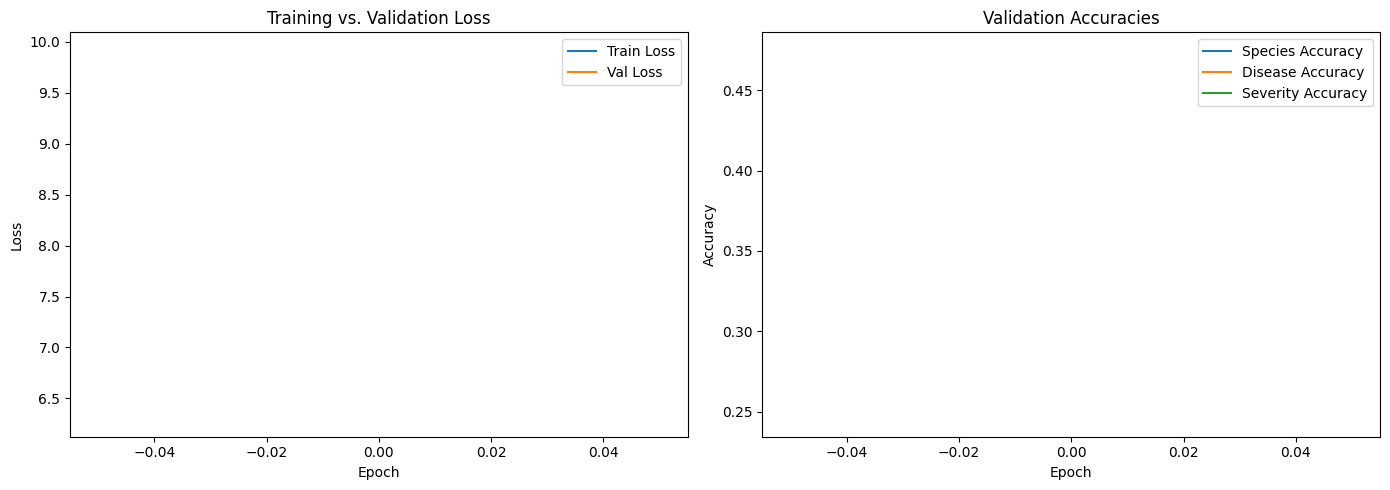

Epoch 2/20
Train Loss: 9.9090
Val Loss: 6.3102
Val Accuracies - Species: 0.4284 | Disease: 0.2381 | Severity: 0.4727
--------------------------------------------------


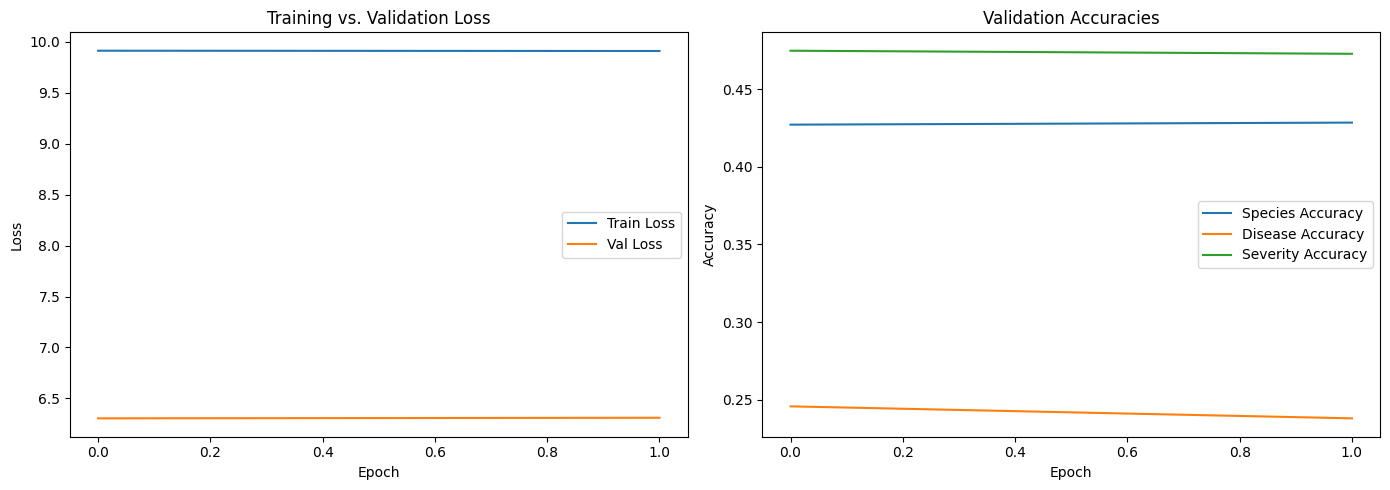

Epoch 3/20
Train Loss: 9.9050
Val Loss: 6.3792
Val Accuracies - Species: 0.4326 | Disease: 0.2346 | Severity: 0.4694
--------------------------------------------------


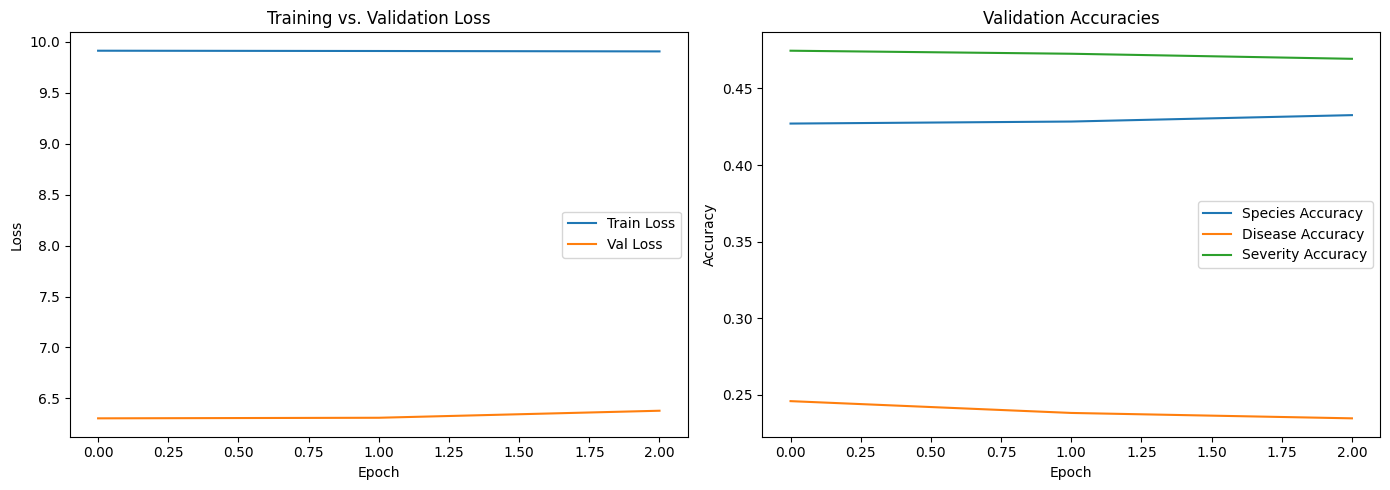

Epoch 4/20
Train Loss: 9.9052
Val Loss: 6.3079
Val Accuracies - Species: 0.4258 | Disease: 0.2405 | Severity: 0.4705
--------------------------------------------------


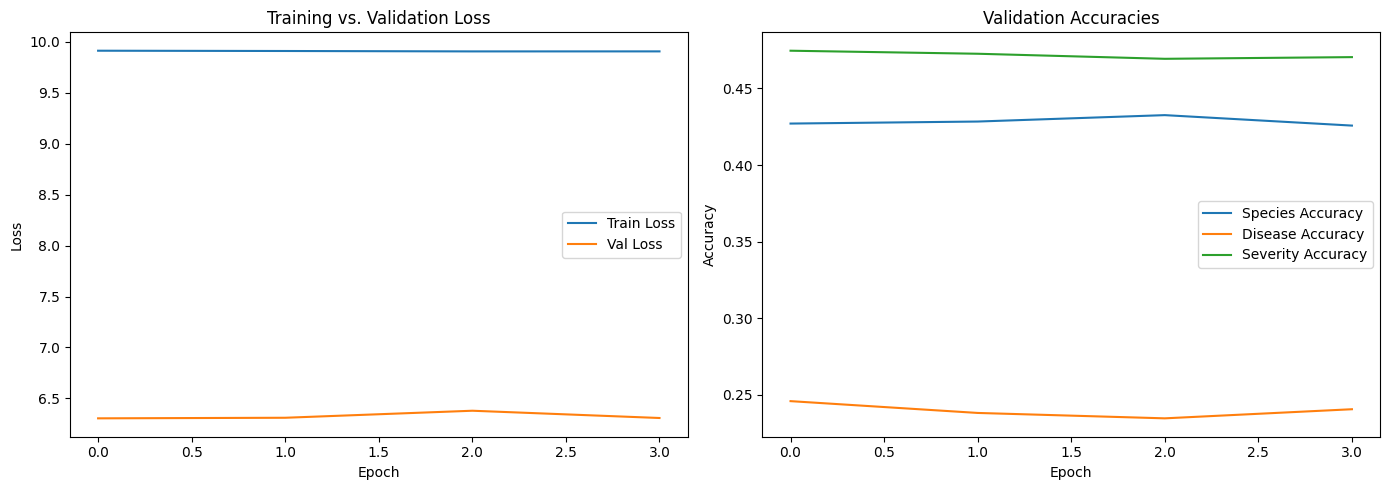

Epoch 5/20
Train Loss: 9.9061
Val Loss: 6.3193
Val Accuracies - Species: 0.4295 | Disease: 0.2284 | Severity: 0.4698
--------------------------------------------------


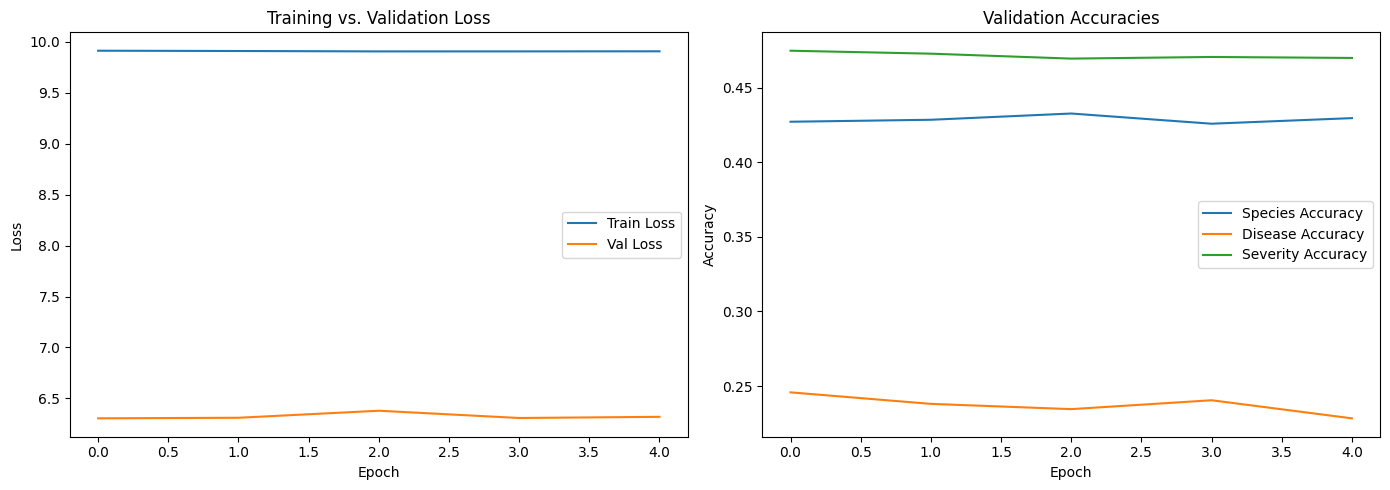

Epoch 6/20
Train Loss: 9.9051
Val Loss: 6.3184
Val Accuracies - Species: 0.4267 | Disease: 0.2328 | Severity: 0.4703
--------------------------------------------------


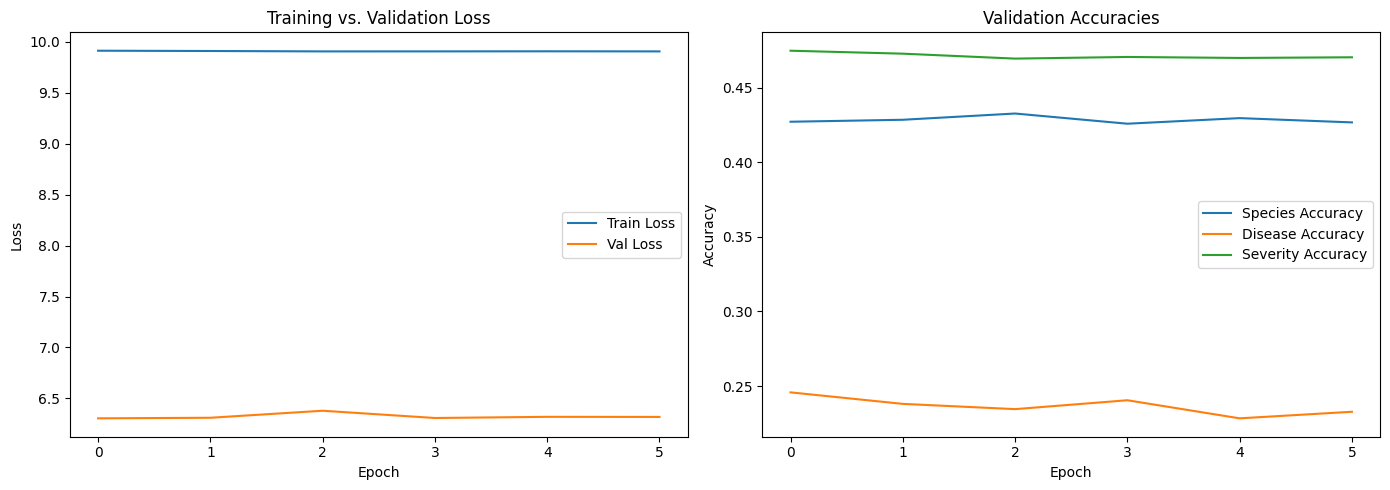

Epoch 7/20
Train Loss: 9.9072
Val Loss: 6.3219
Val Accuracies - Species: 0.4242 | Disease: 0.2313 | Severity: 0.4687
--------------------------------------------------


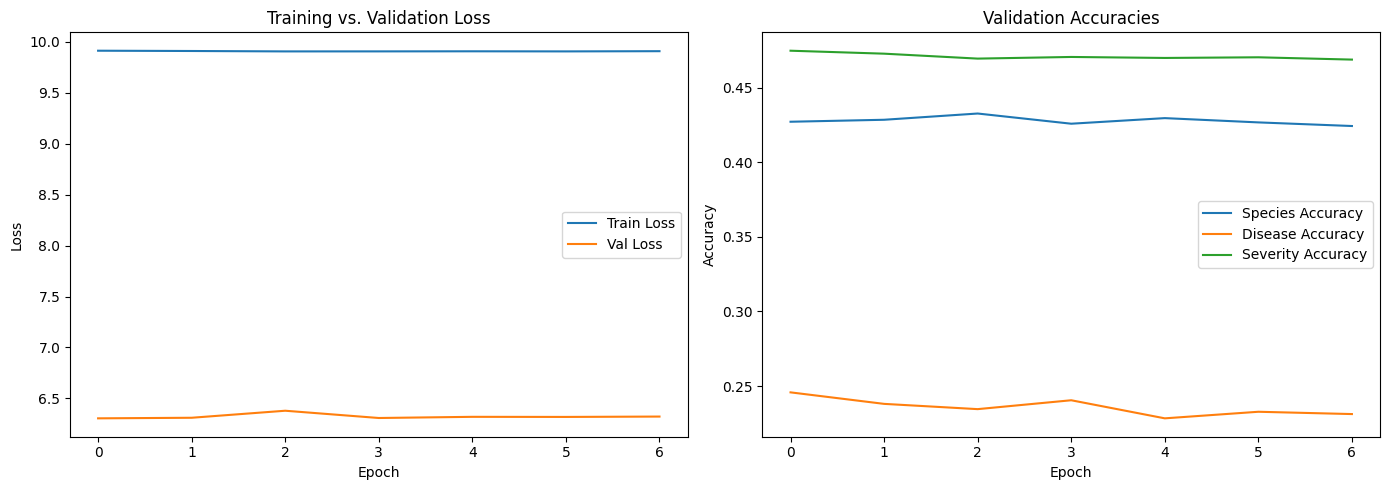

Epoch 8/20
Train Loss: 9.9072
Val Loss: 6.3280
Val Accuracies - Species: 0.4322 | Disease: 0.2330 | Severity: 0.4714
--------------------------------------------------


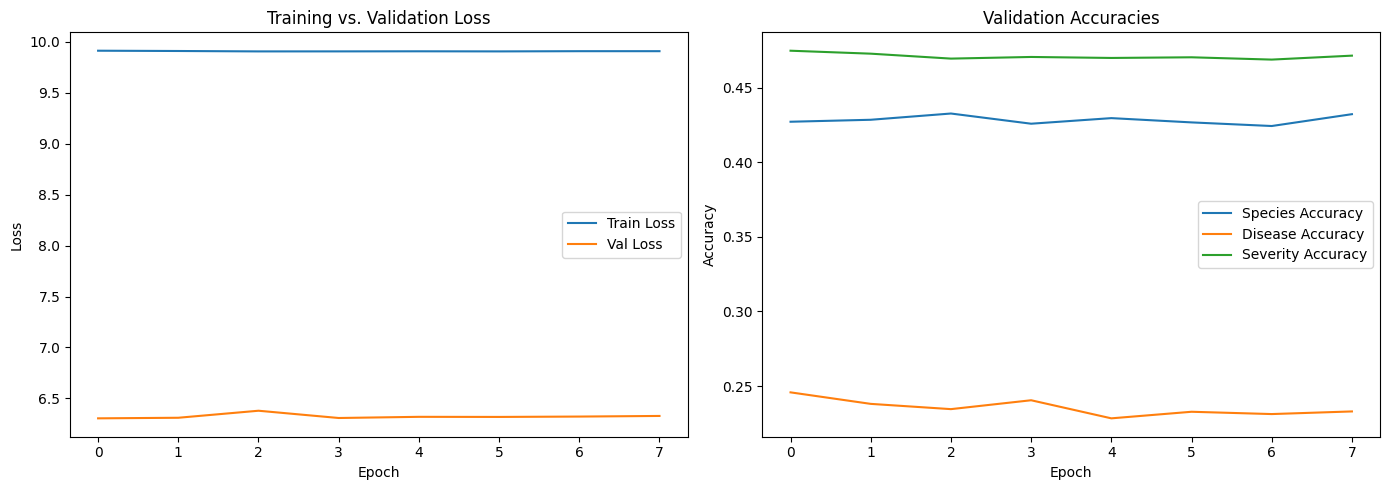

Epoch 9/20
Train Loss: 9.9065
Val Loss: 6.3122
Val Accuracies - Species: 0.4222 | Disease: 0.2372 | Severity: 0.4722
--------------------------------------------------


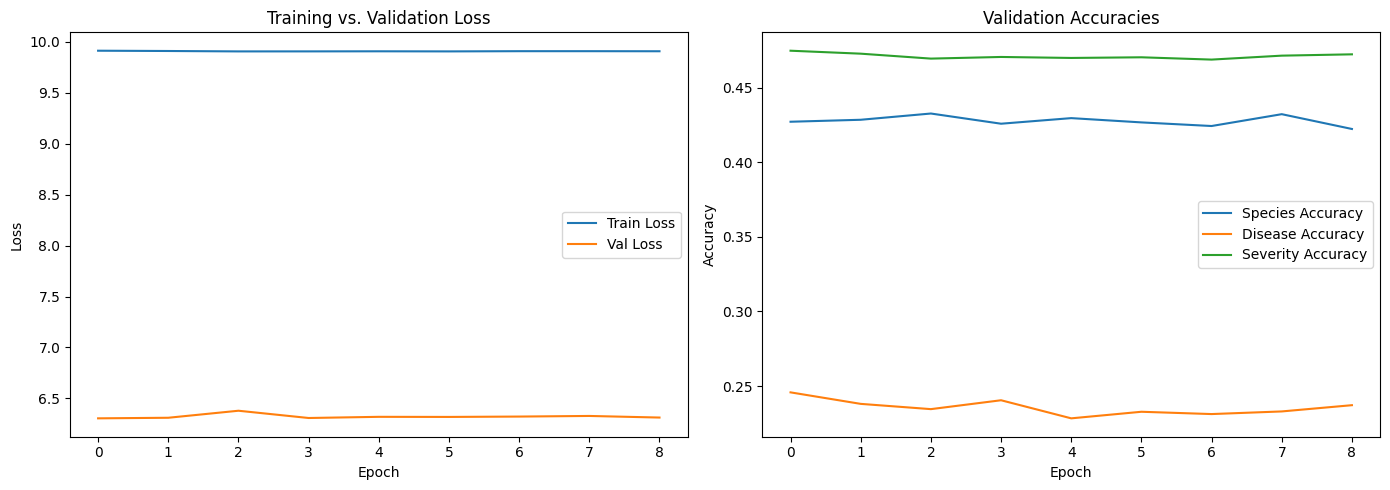

Epoch 10/20
Train Loss: 9.9065
Val Loss: 6.3055
Val Accuracies - Species: 0.4229 | Disease: 0.2401 | Severity: 0.4753
--------------------------------------------------


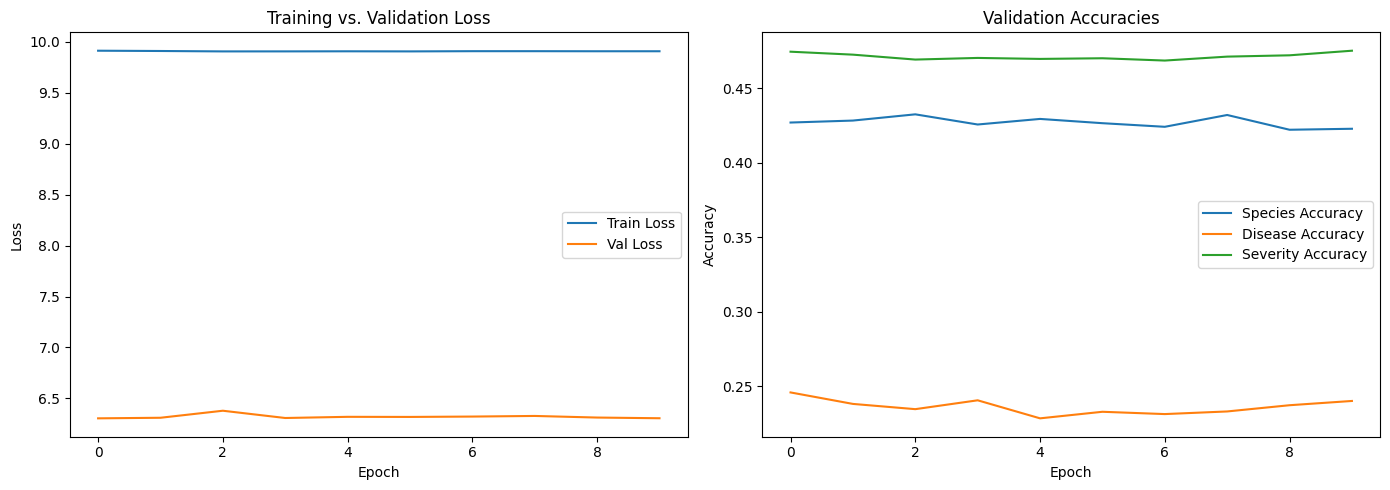

Epoch 11/20
Train Loss: 9.9084
Val Loss: 6.3116
Val Accuracies - Species: 0.4264 | Disease: 0.2297 | Severity: 0.4705
--------------------------------------------------


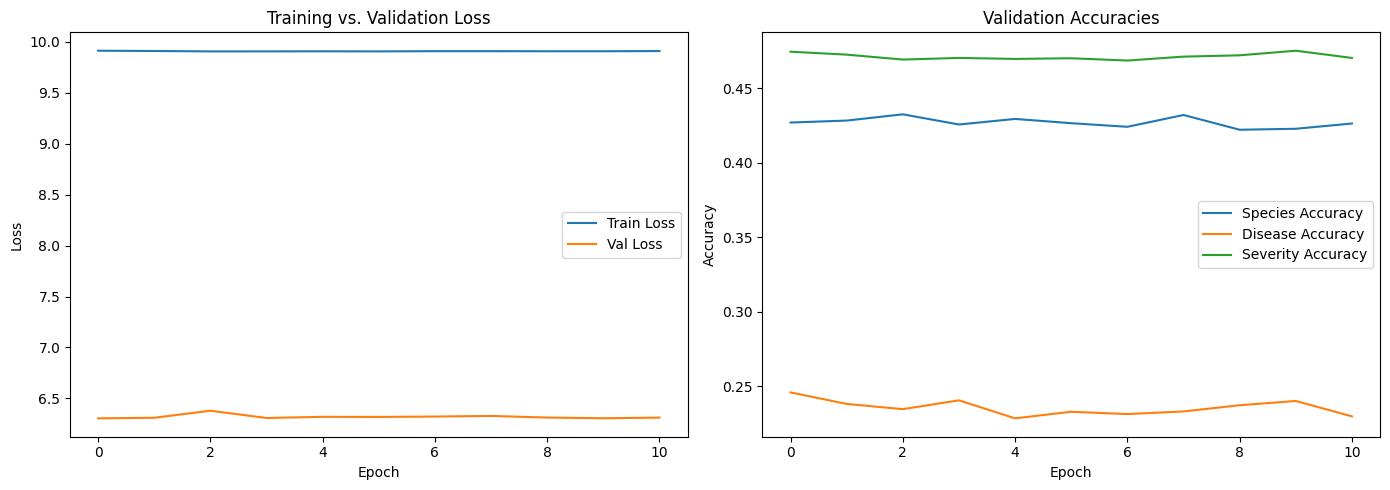

Epoch 12/20
Train Loss: 9.9064
Val Loss: 6.4108
Val Accuracies - Species: 0.4348 | Disease: 0.2390 | Severity: 0.4747
--------------------------------------------------


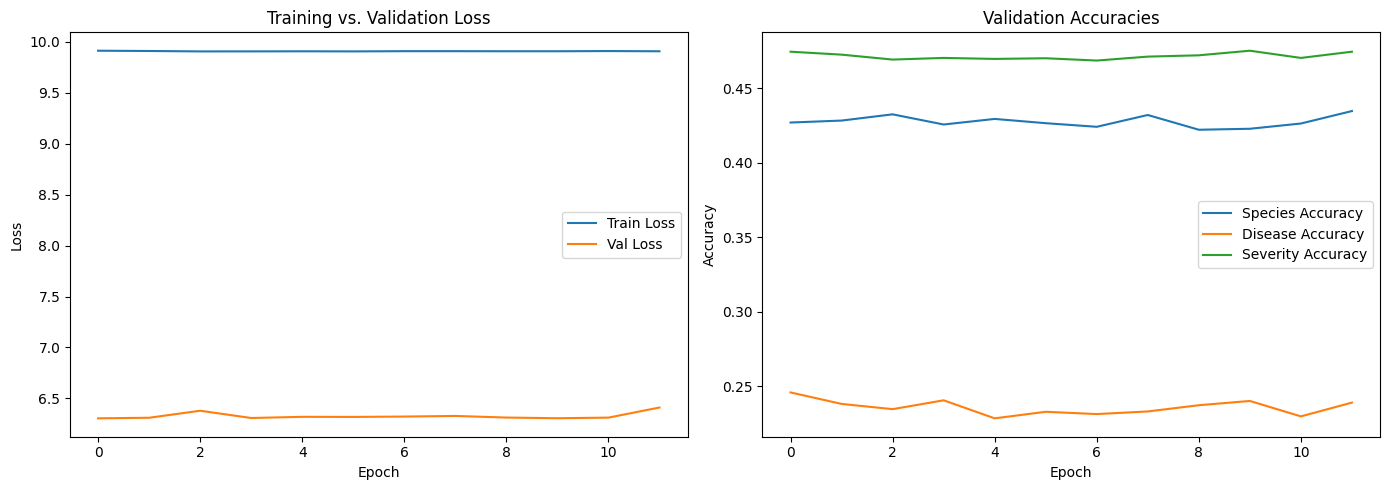

Epoch 13/20
Train Loss: 9.9071
Val Loss: 6.3474
Val Accuracies - Species: 0.4256 | Disease: 0.2388 | Severity: 0.4733
--------------------------------------------------


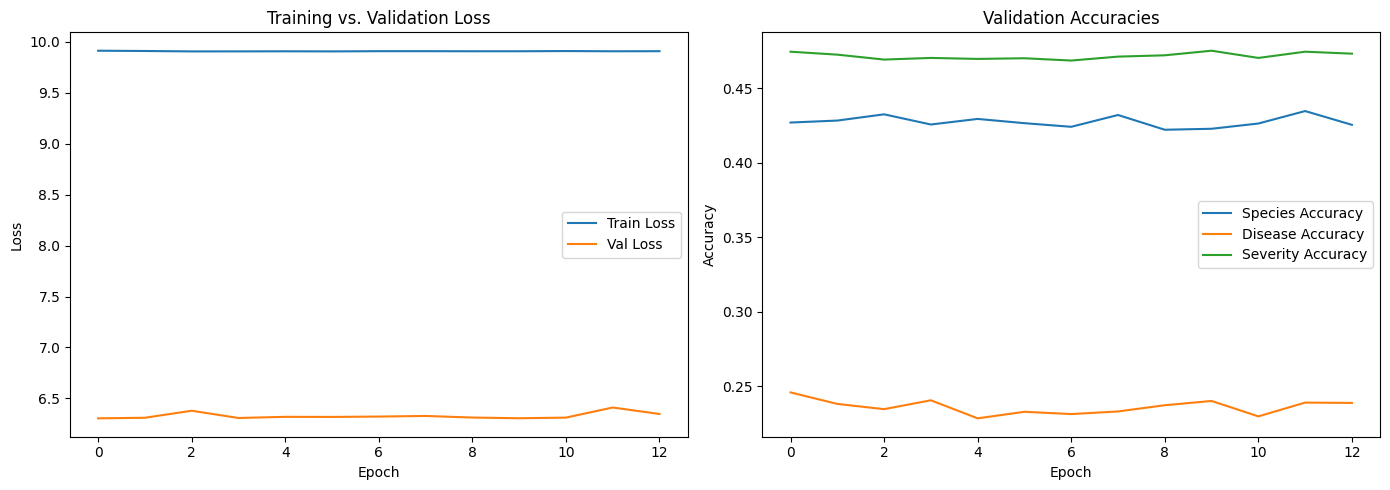

Epoch 14/20
Train Loss: 9.9061
Val Loss: 6.2980
Val Accuracies - Species: 0.4229 | Disease: 0.2379 | Severity: 0.4681
--------------------------------------------------


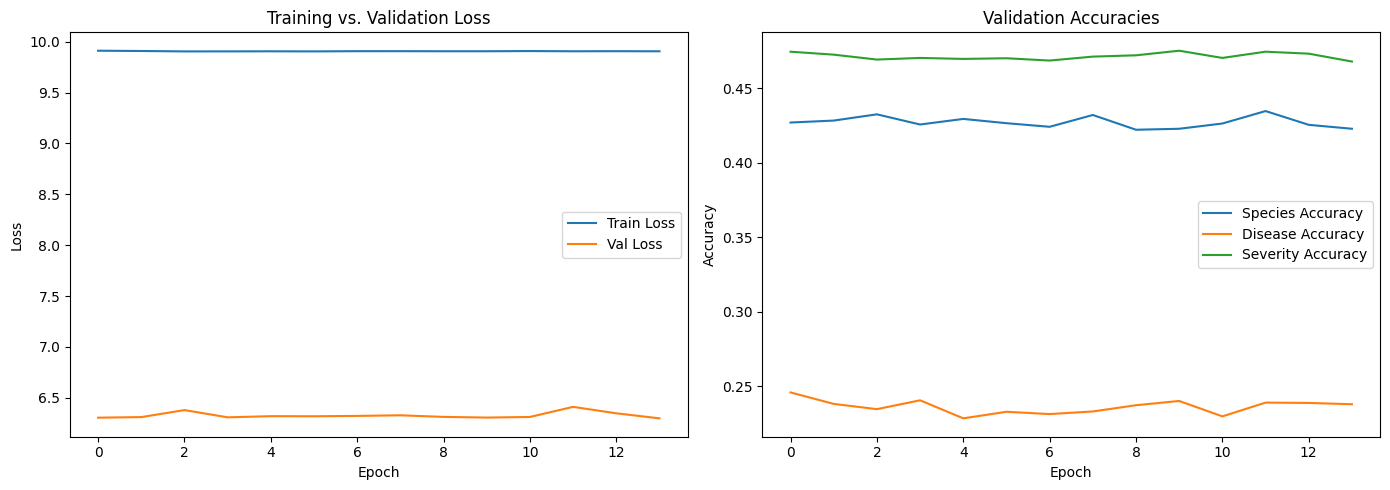

Epoch 15/20
Train Loss: 9.9049
Val Loss: 6.3106
Val Accuracies - Species: 0.4260 | Disease: 0.2346 | Severity: 0.4621
--------------------------------------------------


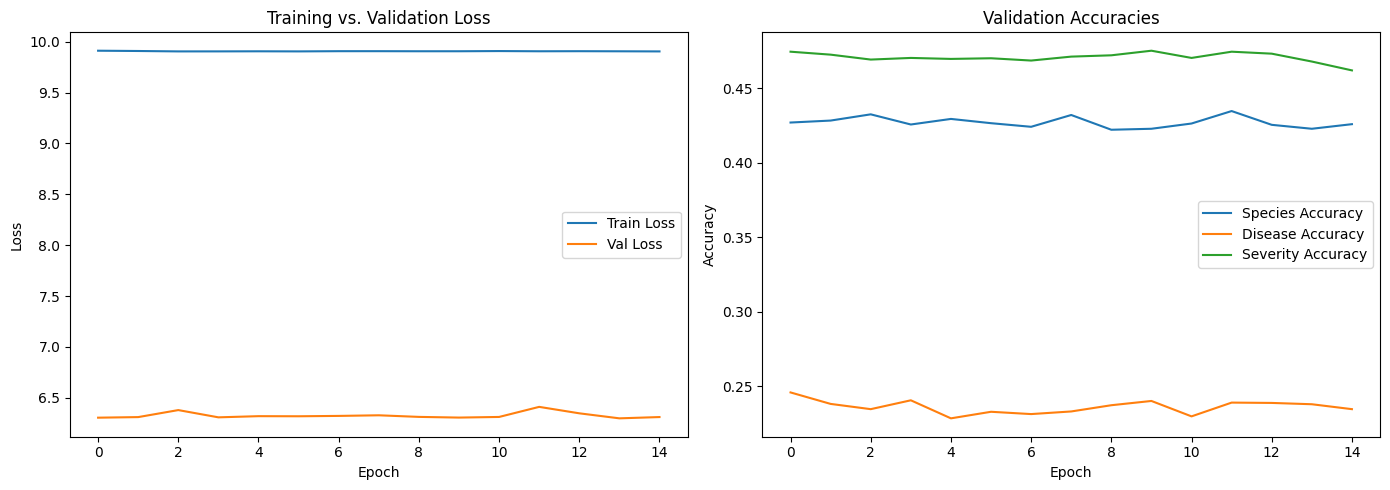

Epoch 16/20
Train Loss: 9.9051
Val Loss: 6.3619
Val Accuracies - Species: 0.4258 | Disease: 0.2330 | Severity: 0.4709
--------------------------------------------------


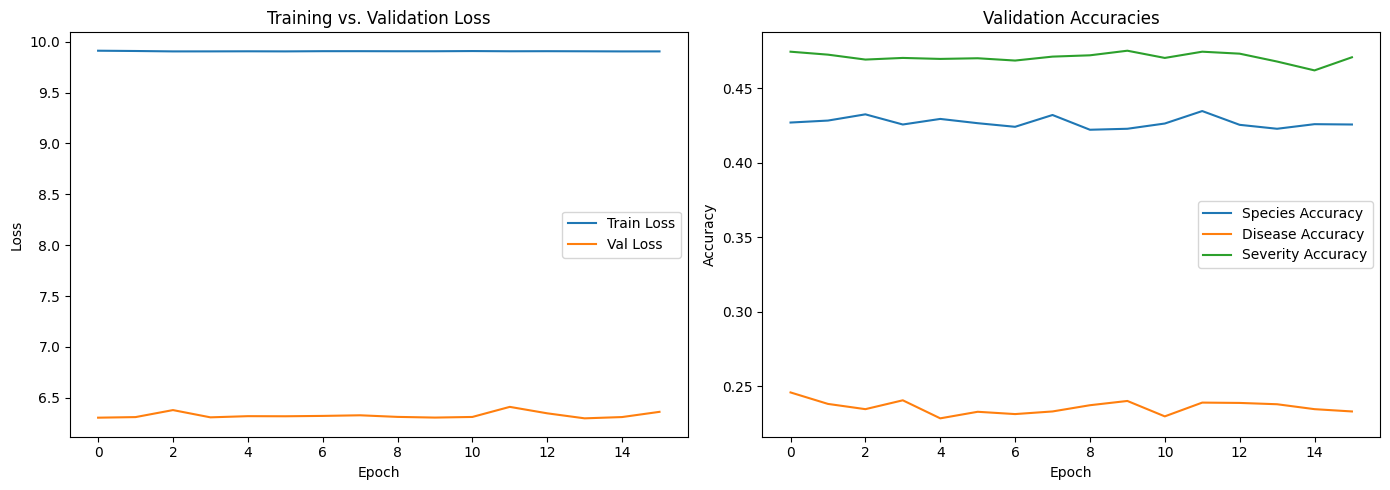

Epoch 17/20
Train Loss: 9.9077
Val Loss: 6.3067
Val Accuracies - Species: 0.4253 | Disease: 0.2374 | Severity: 0.4663
--------------------------------------------------


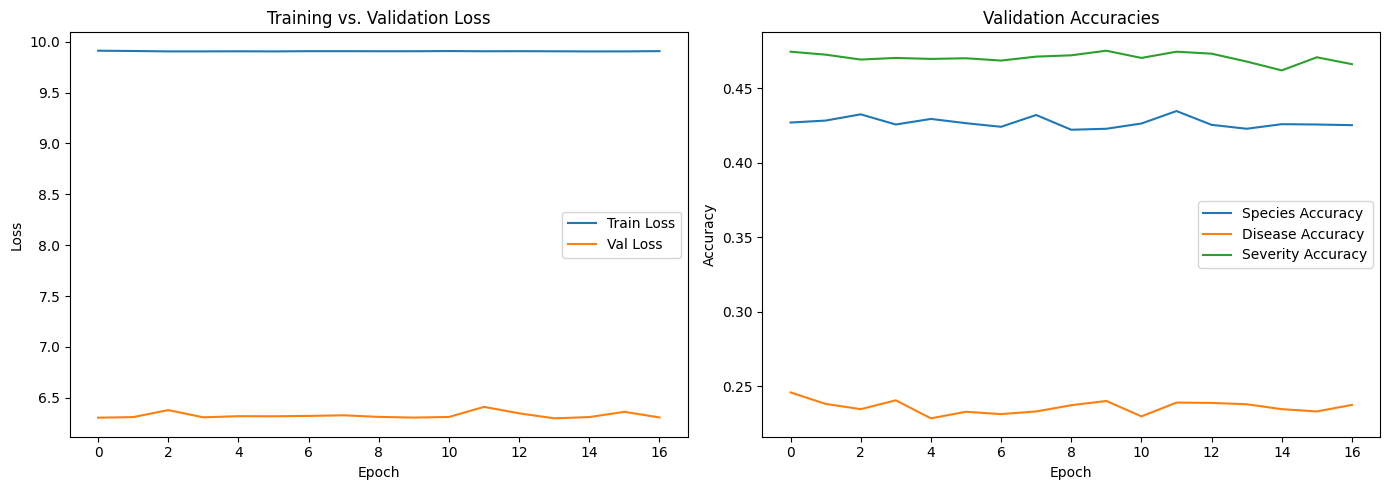

Epoch 18/20
Train Loss: 9.9052
Val Loss: 6.3177
Val Accuracies - Species: 0.4233 | Disease: 0.2350 | Severity: 0.4700
--------------------------------------------------


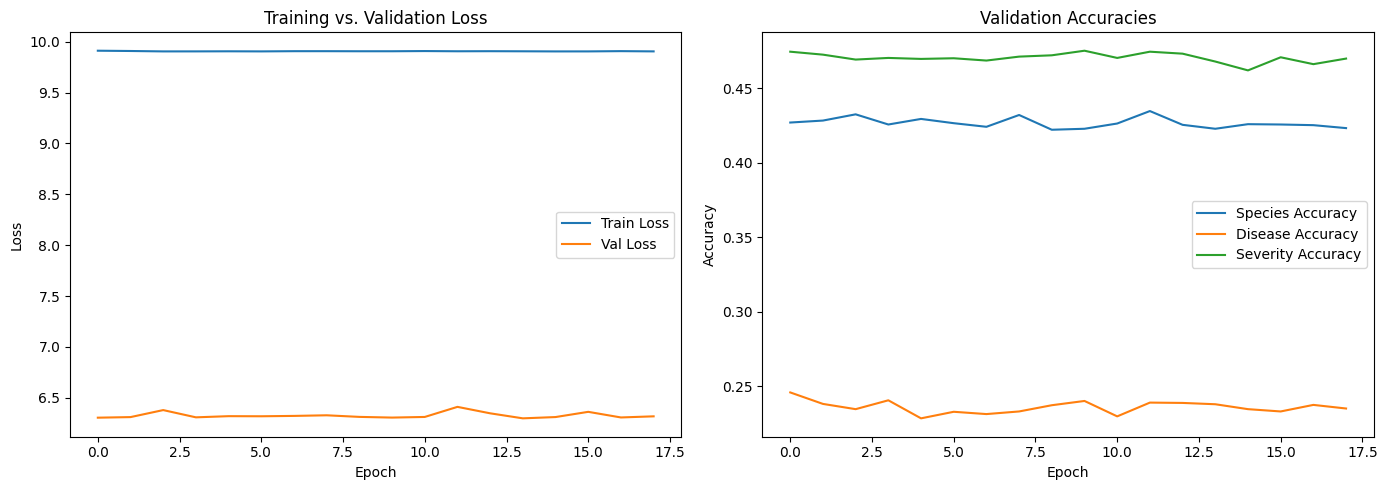

Epoch 19/20
Train Loss: 9.9044
Val Loss: 6.3144
Val Accuracies - Species: 0.4275 | Disease: 0.2399 | Severity: 0.4667
--------------------------------------------------


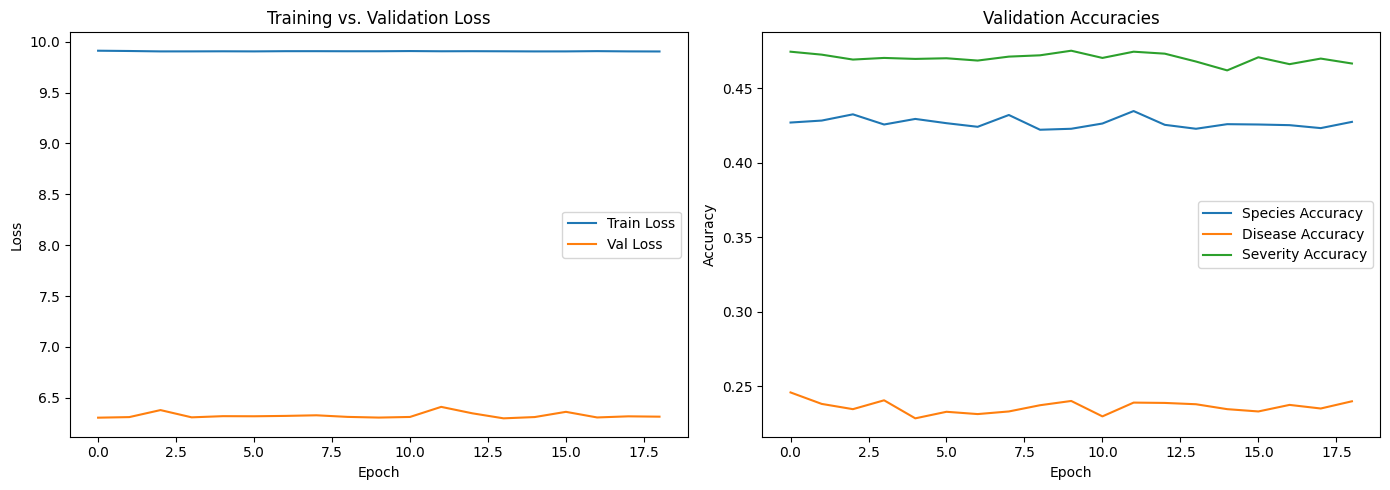

Epoch 20/20
Train Loss: 9.9062
Val Loss: 6.3151
Val Accuracies - Species: 0.4348 | Disease: 0.2330 | Severity: 0.4681
--------------------------------------------------


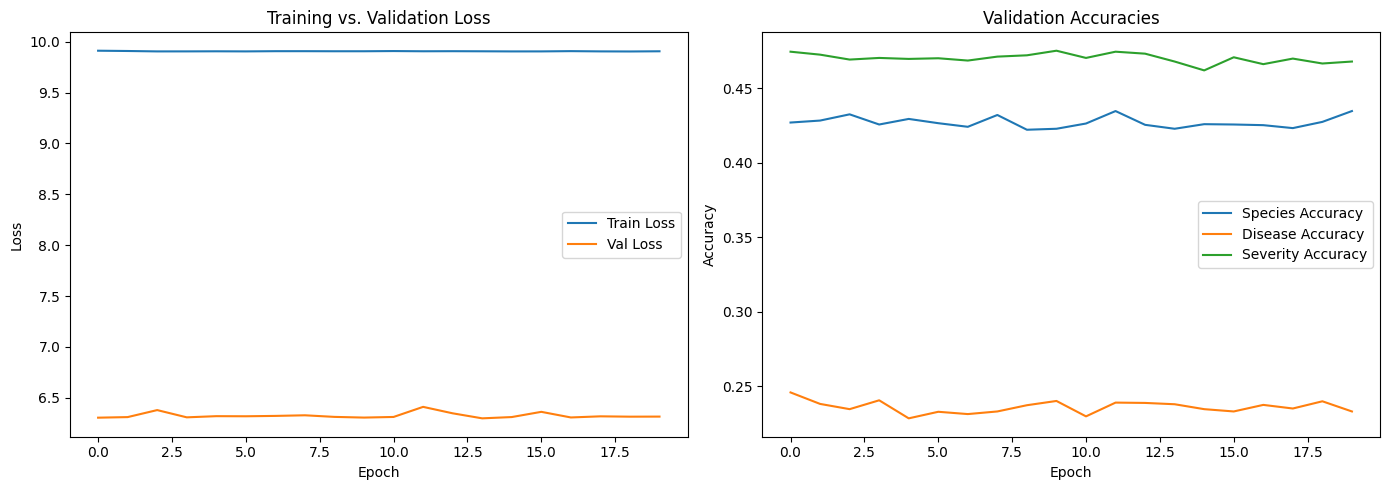

In [51]:
import matplotlib.pyplot as plt

# Tracking lists
train_losses = []
val_losses = []
species_accuracies = []
disease_accuracies = []
severity_accuracies = []

EPOCHS = 20

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc_species, val_acc_disease, val_acc_severity = evaluate(model, val_loader, criterion, device)

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    species_accuracies.append(val_acc_species)
    disease_accuracies.append(val_acc_disease)
    severity_accuracies.append(val_acc_severity)


    # Print metrics
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracies - Species: {val_acc_species:.4f} | Disease: {val_acc_disease:.4f} | Severity: {val_acc_severity:.4f}")
    print("-" * 50)

    # 🔁 Plot live after each epoch
    plt.figure(figsize=(14, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs. Validation Loss")
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(species_accuracies, label="Species Accuracy")
    plt.plot(disease_accuracies, label="Disease Accuracy")
    plt.plot(severity_accuracies, label="Severity Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracies")
    plt.legend()

    plt.tight_layout()
    plt.show()


In [22]:
model = MultiTaskEfficientNet(num_species, num_diseases, num_severities)
model.load_state_dict(torch.load("efficientnet_multitask_weights.pth"))
model = model.to(device)
model.eval()


MultiTaskEfficientNet(
  (efficientnet): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
              (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
     

In [23]:
# Get class label names in correct order
species_labels = [multi_task["species"][i] for i in range(len(multi_task["species"]))]
disease_labels = [multi_task["disease"][i] for i in range(len(multi_task["disease"]))]
severity_labels = [multi_task["severity"][i] for i in range(len(multi_task["severity"]))]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import torch

def get_predictions_and_labels(model, loader, device):
    model.eval()
    true_s, pred_s = [], []
    true_d, pred_d = [], []
    true_v, pred_v = [], []

    with torch.no_grad():
        for images, s_labels, d_labels, v_labels in loader:
            images = images.to(device)
            s_labels = s_labels.to(device)
            d_labels = d_labels.to(device)
            v_labels = v_labels.to(device)

            s_pred, d_pred, v_pred = model(images)
            pred_s.extend(torch.argmax(s_pred, dim=1).cpu().numpy())
            pred_d.extend(torch.argmax(d_pred, dim=1).cpu().numpy())
            pred_v.extend(torch.argmax(v_pred, dim=1).cpu().numpy())

            true_s.extend(s_labels.cpu().numpy())
            true_d.extend(d_labels.cpu().numpy())
            true_v.extend(v_labels.cpu().numpy())

    return (true_s, pred_s), (true_d, pred_d), (true_v, pred_v)

def plot_confusion_matrix(y_true, y_pred, class_names, title, normalize=False):
    cm = confusion_matrix(y_true, y_pred, normalize='true' if normalize else None)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(12, 10))
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()


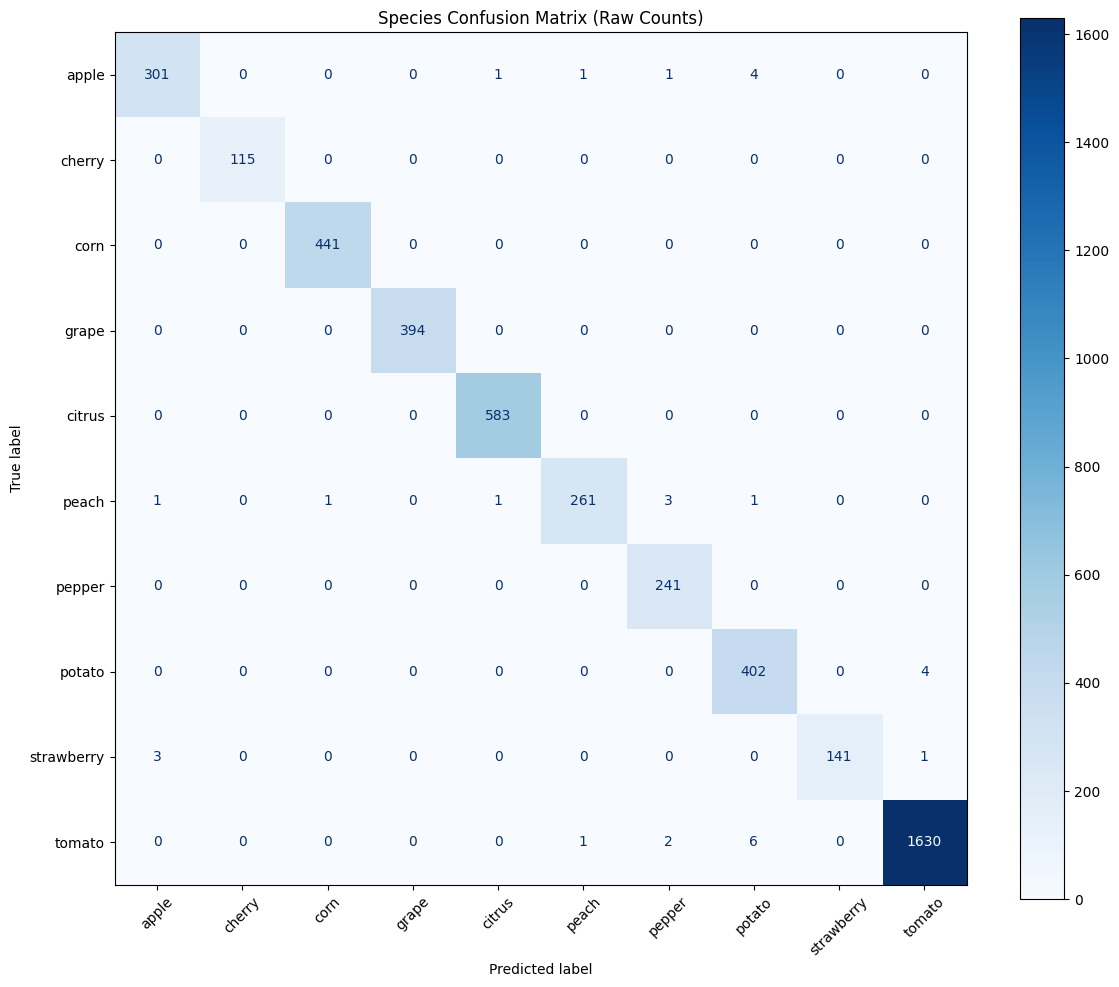

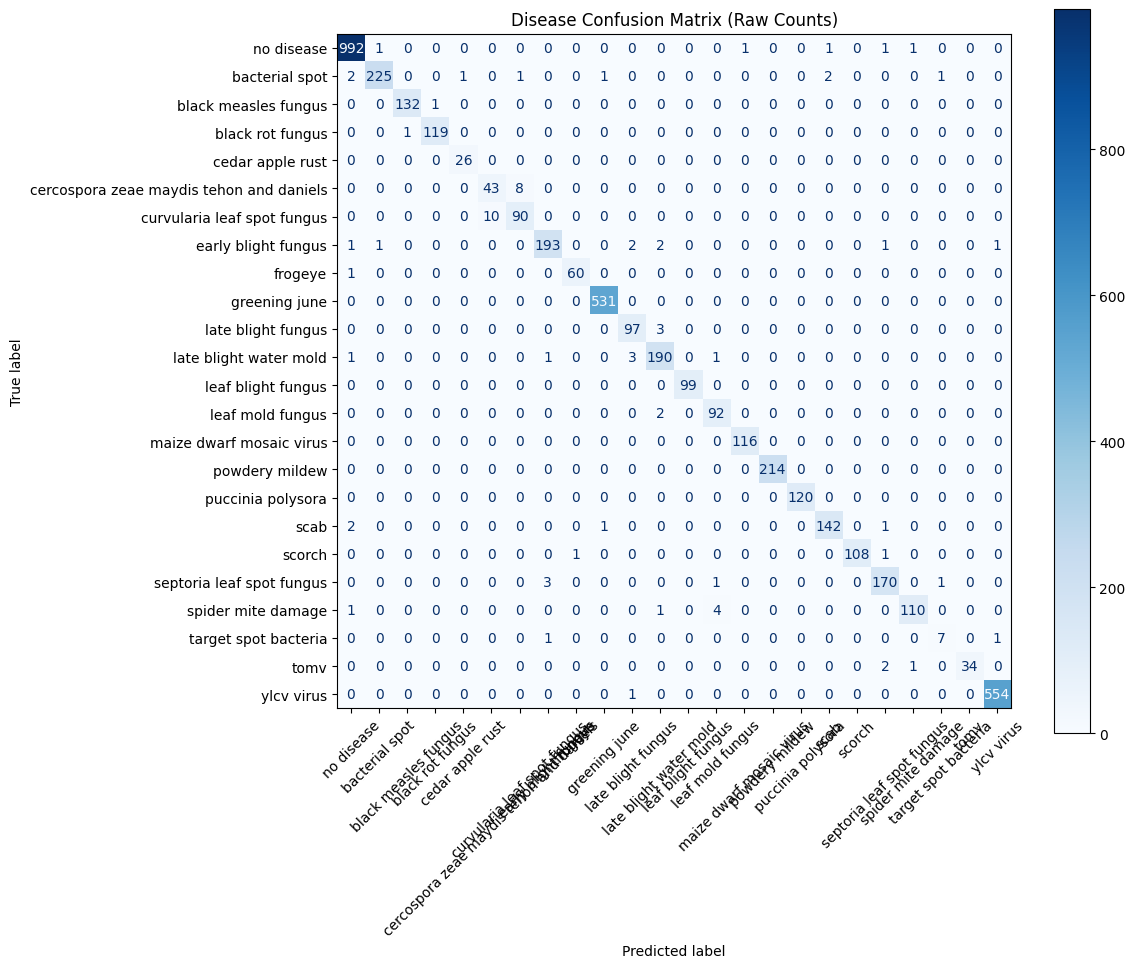

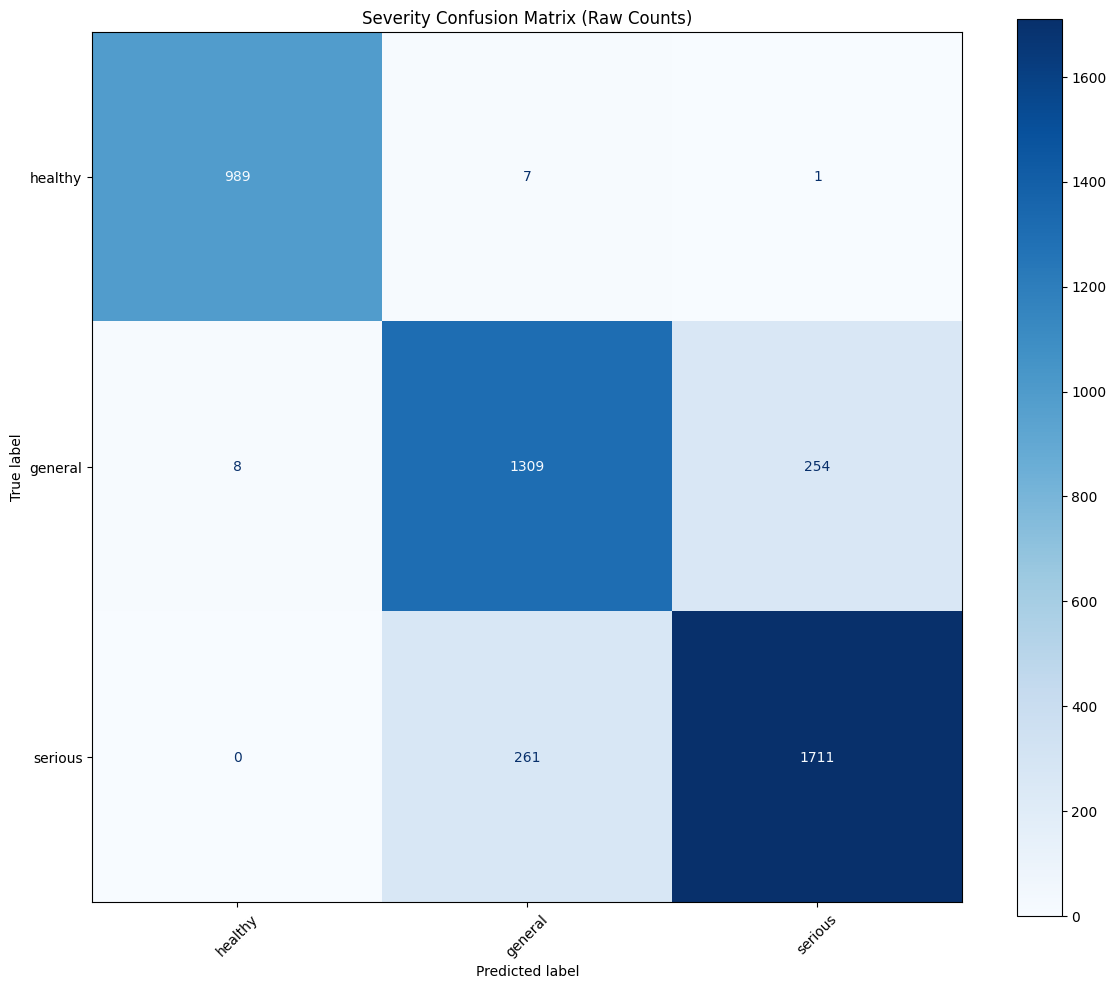

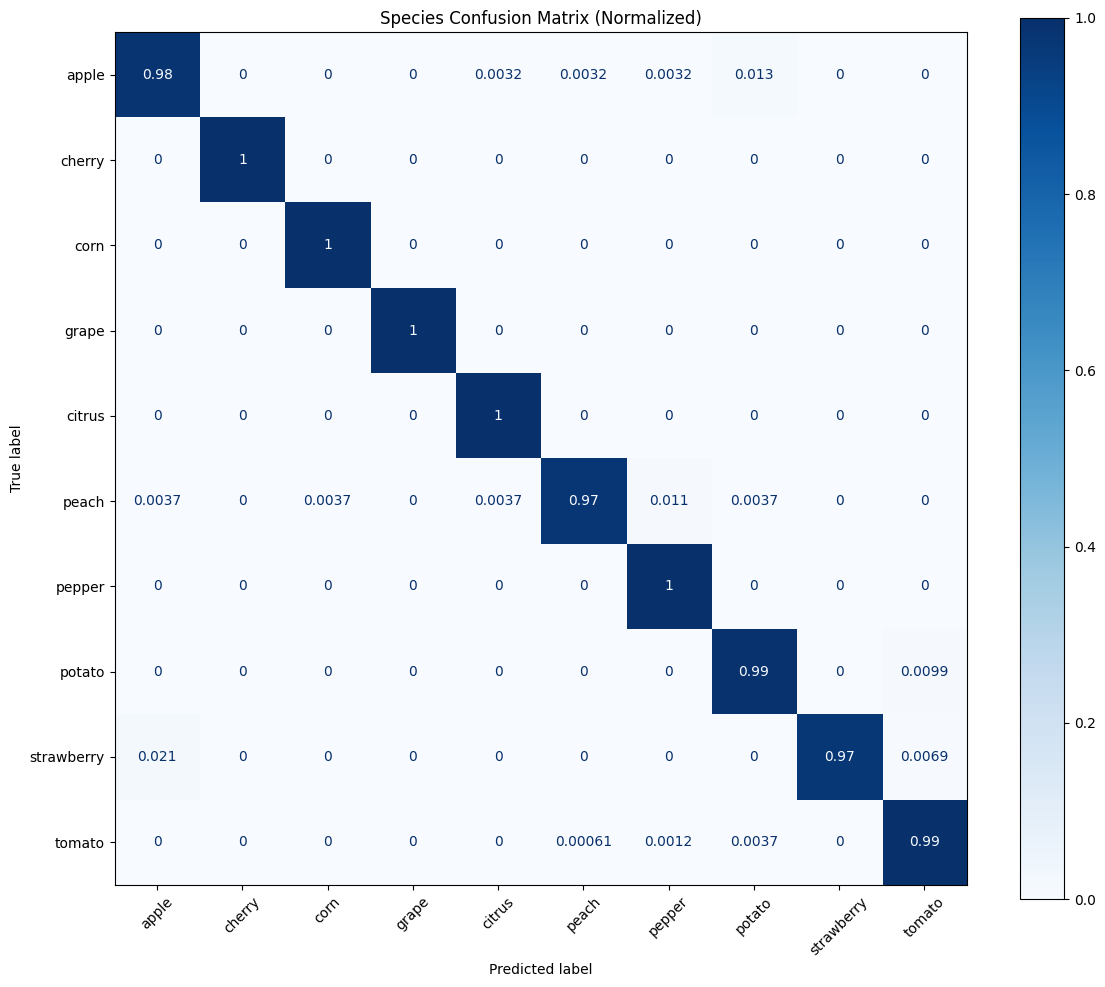

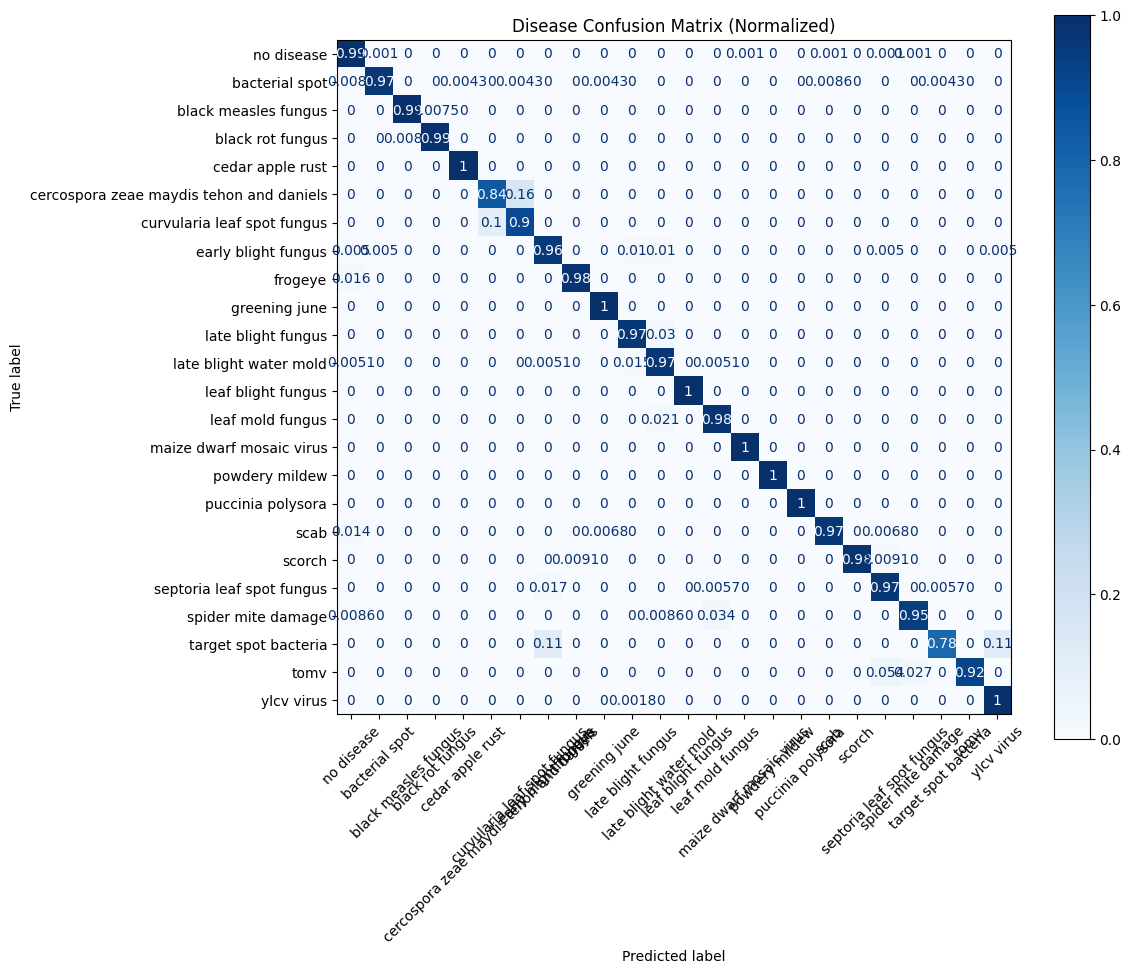

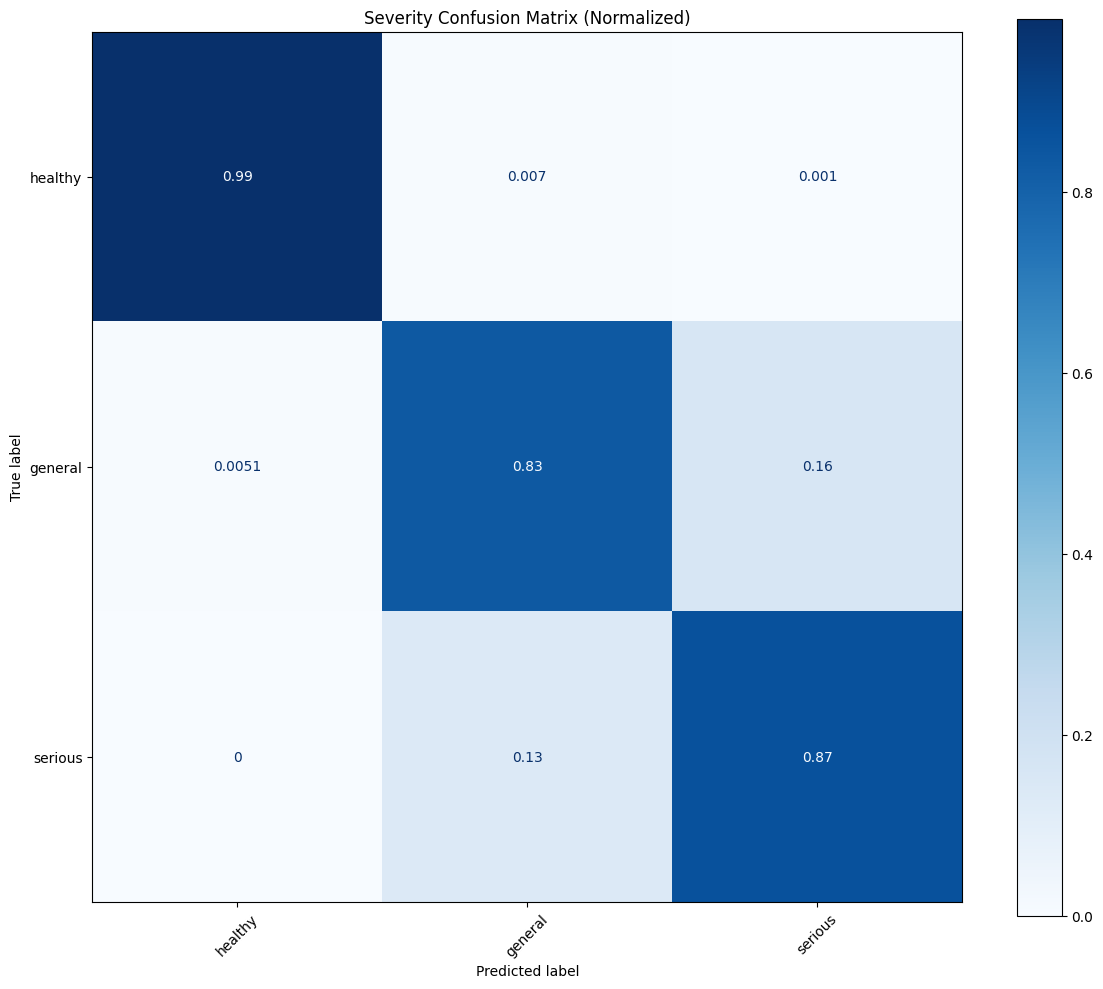

In [24]:
# Get predictions
(spec_true, spec_pred), (disease_true, disease_pred), (severity_true, severity_pred) = get_predictions_and_labels(model, val_loader, device)

# Plot confusion matrices
plot_confusion_matrix(spec_true, spec_pred, species_labels, "Species Confusion Matrix (Raw Counts)")
plot_confusion_matrix(disease_true, disease_pred, disease_labels, "Disease Confusion Matrix (Raw Counts)")
plot_confusion_matrix(severity_true, severity_pred, severity_labels, "Severity Confusion Matrix (Raw Counts)")

# (Optional) Normalized versions
plot_confusion_matrix(spec_true, spec_pred, species_labels, "Species Confusion Matrix (Normalized)", normalize=True)
plot_confusion_matrix(disease_true, disease_pred, disease_labels, "Disease Confusion Matrix (Normalized)", normalize=True)
plot_confusion_matrix(severity_true, severity_pred, severity_labels, "Severity Confusion Matrix (Normalized)", normalize=True)


In [25]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


def evaluate_metrics(y_true, y_pred, class_names, title):
    print(f"\n🔹 {title} Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Compute confusion matrix for specificity
    cm = confusion_matrix(y_true, y_pred)
    TP = np.diag(cm)
    FP = cm.sum(axis=0) - TP
    FN = cm.sum(axis=1) - TP
    TN = cm.sum() - (FP + FN + TP)

    with np.errstate(divide='ignore', invalid='ignore'):
        specificity = TN / (TN + FP)
        specificity[np.isnan(specificity)] = 0.0

    print("Specificity (per class):")
    for name, spec in zip(class_names, specificity):
        print(f"{name:25}: {spec:.4f}")


# Get predictions
(spec_true, spec_pred), (disease_true, disease_pred), (severity_true, severity_pred) = get_predictions_and_labels(model, val_loader, device)

# Species
evaluate_metrics(spec_true, spec_pred, species_labels, "Species")

# Disease
evaluate_metrics(disease_true, disease_pred, disease_labels, "Disease")

# Severity
evaluate_metrics(severity_true, severity_pred, severity_labels, "Severity")



🔹 Species Classification Report:

              precision    recall  f1-score   support

       apple     0.9869    0.9773    0.9821       308
      cherry     1.0000    1.0000    1.0000       115
        corn     0.9977    1.0000    0.9989       441
       grape     1.0000    1.0000    1.0000       394
      citrus     0.9966    1.0000    0.9983       583
       peach     0.9924    0.9739    0.9831       268
      pepper     0.9757    1.0000    0.9877       241
      potato     0.9734    0.9901    0.9817       406
  strawberry     1.0000    0.9724    0.9860       145
      tomato     0.9969    0.9945    0.9957      1639

    accuracy                         0.9932      4540
   macro avg     0.9920    0.9908    0.9913      4540
weighted avg     0.9932    0.9932    0.9932      4540

Specificity (per class):
apple                    : 0.9991
cherry                   : 1.0000
corn                     : 0.9998
grape                    : 1.0000
citrus                   : 0.9995
peach      

In [26]:
import matplotlib.pyplot as plt
import torch

import random
import matplotlib.pyplot as plt
import numpy as np

def show_random_predictions(model, dataset, device, species_labels, disease_labels, severity_labels, num_samples=5):
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)

    for idx in indices:
        image, s_true, d_true, v_true = dataset[idx]
        image_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            s_pred, d_pred, v_pred = model(image_tensor)
            s_pred = torch.argmax(s_pred, dim=1).item()
            d_pred = torch.argmax(d_pred, dim=1).item()
            v_pred = torch.argmax(v_pred, dim=1).item()

        # Convert image to numpy for display
        img_np = image.permute(1, 2, 0).numpy()
        img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]  # unnormalize
        img_np = np.clip(img_np, 0, 1)

        plt.figure(figsize=(4, 4))
        plt.imshow(img_np)
        plt.axis("off")

        title = (
            f"✅ True:\nSpecies: {species_labels[s_true]}\n"
            f"Disease: {disease_labels[d_true]}\n"
            f"Severity: {severity_labels[v_true]}\n\n"
            f"🔮 Predicted:\nSpecies: {species_labels[s_pred]}\n"
            f"Disease: {disease_labels[d_pred]}\n"
            f"Severity: {severity_labels[v_pred]}"
        )

        plt.title(title, fontsize=10)
        plt.tight_layout()
        plt.show()


/tmp/ipykernel_290043/3076944715.py:41: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_290043/3076944715.py:41: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/amzeplin/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/amzeplin/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


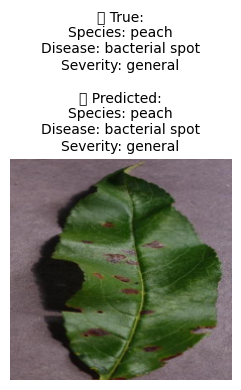

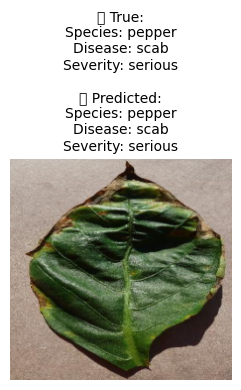

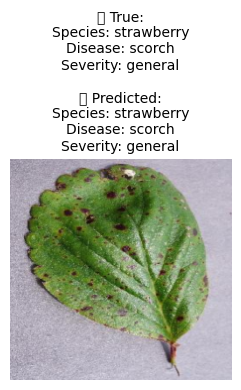

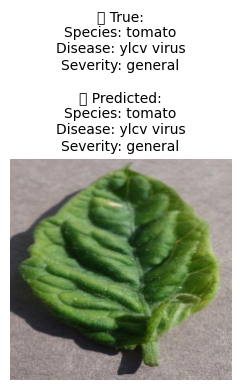

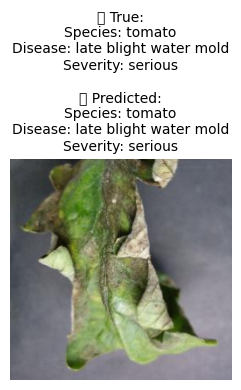

In [27]:
show_random_predictions(
    model,
    val_ds,
    device,
    species_labels,
    disease_labels,
    severity_labels,
    num_samples=5  # change as needed
)


In [28]:
import requests
from PIL import Image
from io import BytesIO
import torch
import numpy as np
import matplotlib.pyplot as plt

def predict_from_url(url, model, device, species_labels, disease_labels, severity_labels, transform):
    # Step 1: Load image from URL
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    # Step 2: Apply same transform used during validation
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Step 3: Model prediction
    model.eval()
    with torch.no_grad():
        s_pred, d_pred, v_pred = model(img_tensor)
        s_pred = torch.argmax(s_pred, dim=1).item()
        d_pred = torch.argmax(d_pred, dim=1).item()
        v_pred = torch.argmax(v_pred, dim=1).item()

    # Step 4: Display image and prediction
    img_np = np.array(img)
    plt.imshow(img_np)
    plt.axis("off")
    plt.title("Prediction from URL")
    plt.show()

    print(f"🔮 Predicted:")
    print(f"Species:  {species_labels[s_pred]}")
    print(f"Disease:  {disease_labels[d_pred]}")
    print(f"Severity: {severity_labels[v_pred]}")


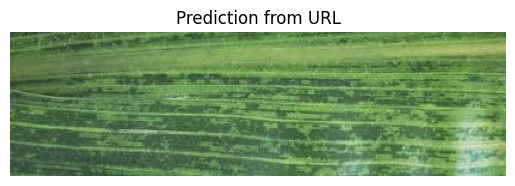

🔮 Predicted:
Species:  corn
Disease:  maize dwarf mosaic virus
Severity: general


In [29]:
# Example image URL (replace with your own)
image_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSXN8aqgcoYU7O4X_jLSb1d04wt-HFPJO0eQQ&s"

predict_from_url(
    image_url,
    model,
    device,
    species_labels,
    disease_labels,
    severity_labels,
    val_transform  # use same transform as validation
)


In [30]:
def evaluate_model(model, loader, device, species_loss_fn, disease_loss_fn, severity_loss_fn):
    model.eval()
    total_loss = 0
    correct_species, correct_disease, correct_severity = 0, 0, 0
    total_samples = 0

    with torch.no_grad():
        for images, s_labels, d_labels, v_labels in loader:
            images = images.to(device)
            s_labels = s_labels.to(device)
            d_labels = d_labels.to(device)
            v_labels = v_labels.to(device)

            s_pred, d_pred, v_pred = model(images)

            # Compute losses
            s_loss = species_loss_fn(s_pred, s_labels)
            d_loss = disease_loss_fn(d_pred, d_labels)
            v_loss = severity_loss_fn(v_pred, v_labels)
            loss = s_loss + d_loss + 2.0 * v_loss  # match training loss weighting

            total_loss += loss.item()

            # Compute accuracies
            _, s_pred_class = torch.max(s_pred, dim=1)
            _, d_pred_class = torch.max(d_pred, dim=1)
            _, v_pred_class = torch.max(v_pred, dim=1)

            correct_species += (s_pred_class == s_labels).sum().item()
            correct_disease += (d_pred_class == d_labels).sum().item()
            correct_severity += (v_pred_class == v_labels).sum().item()
            total_samples += images.size(0)

    avg_loss = total_loss / len(loader)
    acc_species = correct_species / total_samples
    acc_disease = correct_disease / total_samples
    acc_severity = correct_severity / total_samples

    return avg_loss, acc_species, acc_disease, acc_severity


In [31]:
# Define the loss functions (if you haven't already)
species_loss_fn = nn.CrossEntropyLoss()
disease_loss_fn = nn.CrossEntropyLoss()
severity_loss_fn = nn.CrossEntropyLoss()

# Evaluate
val_loss, val_acc_species, val_acc_disease, val_acc_severity = evaluate_model(
    model,
    val_loader,
    device,
    species_loss_fn,
    disease_loss_fn,
    severity_loss_fn
)

# Display results
print(f" Validation Loss: {val_loss:.4f}")
print(f" Species Accuracy:  {val_acc_species*100:.2f}%")
print(f" Disease Accuracy:  {val_acc_disease*100:.2f}%")
print(f" Severity Accuracy: {val_acc_severity*100:.2f}%")


 Validation Loss: 2.1941
 Species Accuracy:  99.32%
 Disease Accuracy:  98.33%
 Severity Accuracy: 88.30%
